In [7]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import shap
import joblib
import matplotlib.pyplot as plt

data_path = 'data/'

#Loading relevant tables
student_info = pd.read_csv(data_path + 'studentInfo.csv')
student_vle = pd.read_csv(data_path + 'studentVle.csv')
student_assessment = pd.read_csv(data_path + 'studentAssessment.csv')
assessments = pd.read_csv(data_path + 'assessments.csv')




,The Oulad dataset is relational so we need to load the different datasets and merge them together
we start from the studentInfo as the base table
aggregate StudentVle to student level
merge studentAssessment with assessments
aggregate assessment data to student level
merge engineered features back into studentInfo
,


In [8]:
#creating the target variable
student_info['at_risk'] = student_info['final_result'].apply(
    lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0
)

#early days is the time limit in which the model can access to come up with a result as we are chasing early intervention
early_days = 30
early_vle = student_vle[student_vle['date'] <= early_days]

# features for the learning environment
vle_features = (
    early_vle
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(
        total_clicks=('sum_click', 'sum'),
        avg_clicks=('sum_click', 'mean'),
        vle_records=('sum_click', 'count')
    )
    .reset_index()
)

# full assessment details
assessment_full = student_assessment.merge(
    assessments,
    on='id_assessment',
    how='left'
)

early_assessments = assessment_full[assessment_full['date_submitted'] <= early_days]

assessment_features = (
    early_assessments
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(
        avg_score=('score', 'mean'),
        assessment_count=('score', 'count'),
    )
    .reset_index()
)

#merge features
df = student_info.merge(
    vle_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

df = df.merge(
    assessment_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

print(df.shape)
print(df.columns)
print(df.head())

(32593, 18)
Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'at_risk',
       'total_clicks', 'avg_clicks', 'vle_records', 'avg_score',
       'assessment_count'],
      dtype='str')
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     

Handling missing values and encoding categorical variables

In [9]:
#handling nulls
print('before handling\t' ,df.isnull().sum())

#fill nulls with 0 where it makes sense
feature_cols = [
    'total_clicks',
    'avg_clicks',
    'vle_records',
    'avg_score',
    'assessment_count',
]

df[feature_cols] = df[feature_cols].fillna(0)
#fill imd_band with 'Unknown'
df['imd_band'] = df['imd_band'].fillna('Unknown')

print('after handling\t',df.isnull().sum())

#dropping all the columns that contain final outcomes that lead to data leakage
df = df.drop(columns=['id_student', 'final_result',])





before handling	 code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                 1111
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
at_risk                     0
total_clicks             3751
avg_clicks               3751
vle_records              3751
avg_score               11302
assessment_count        11289
dtype: int64
after handling	 code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
at_risk                 0
total_clicks            0
avg_clicks              0
vle_records             

Machine learning stage

In [12]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier



#Defining the features and target
x = df.drop(columns=['at_risk'])
y = df['at_risk']


print(x.shape)
print(y.shape)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


#Moved encoding after splitting
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

#aligning columns
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

#Some columns have characters which XGBoost does not allow so we are going to change these characters
x_train.columns = x_train.columns.str.replace(r'[\[\]<]', '', regex=True)
x_test.columns = x_test.columns.str.replace(r'[\[\]<]', '', regex=True)


model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
)

model.fit(x_train, y_train)


(32593, 15)
(32593,)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Evaluate the model

Accuracy: 0.7708237459733088
ROC-AUC: 0.8517414824652626
              precision    recall  f1-score   support

           0       0.73      0.81      0.77      3077
           1       0.81      0.73      0.77      3442

    accuracy                           0.77      6519
   macro avg       0.77      0.77      0.77      6519
weighted avg       0.78      0.77      0.77      6519



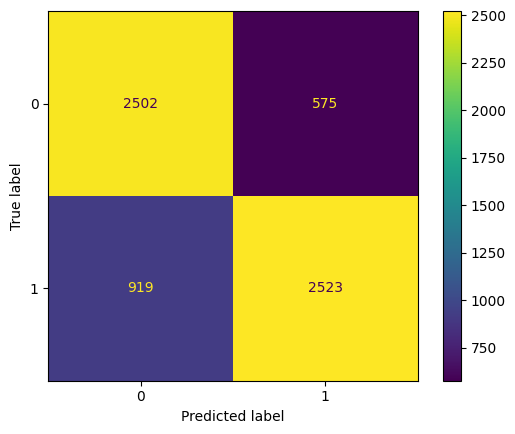

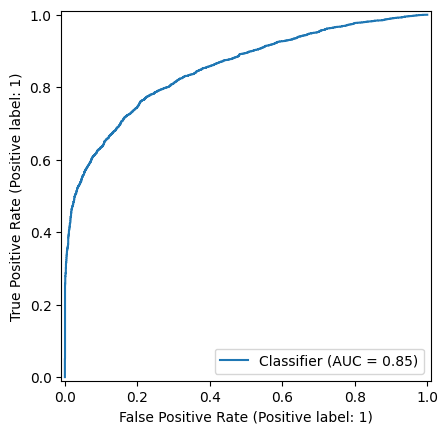

ValueError: All arrays must be of the same length

In [11]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt

y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.show()

importance_df = pd.DataFrame({
    "feature": x.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(20))

importance_df.head(15).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10,6)
)